# Test-set evaluation: all `results/` runs

For each `(d, horizon_h)` pair, `horizon_h` is passed directly to `model.predict(..., horizon_h=...)` (same as `evaluate.horizon_h` in training configs).  
Scored length per block: `horizon_h - d + 1`.

One run per `(model_name, d)` is kept (newest `model.pkl` mtime) to avoid duplicate stems from reruns.

**XGB / `xgb_sarimax`:** records `feature_importances_` from the fitted booster (global, training-data importances). The same values are stored for every `(d, horizon_h)` tuple that loads that pickle.

**L1 (`linear_l1`):** lists every feature whose fitted Lasso coefficient is non-zero (`|coef| > 1e-10`). If the run trained with `standardize=True`, coefficients refer to **scaled** features.

In [41]:
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import yaml
from IPython.display import display

from omegaconf import DictConfig, OmegaConf

from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.split import make_split
from modeling.evaluate import _load_run
from modeling.models.gbm import XGBModel
from modeling.models.linear import RegularizedLinearModel
from modeling.models.xgb_sarimax import xgb_sarimax

RESULTS_ROOT = Path("results")
# (d, horizon_h) — second value is passed to predict as horizon_h
DH_GRID = [(1, 1), (1, 5), (7, 7), (7, 11)]

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.max_rows = 200

In [42]:
def get_model(stem: str):
    cfg = OmegaConf.create({"load_model": stem})
    model_path, run_cfg = _load_run(cfg)
    with open(model_path, "rb") as f:
        saved = pickle.load(f)
    model = saved["model"]
    feature_cols = saved["feature_cols"]
    feat_params = SimpleNamespace(**saved["feat_params"])
    return model, feature_cols, feat_params, run_cfg


def build_data(run_cfg: DictConfig, feat_params: Any) -> pd.DataFrame:
    pothole_df, weather_df = build_daily(run_cfg)
    feat_df = assemble_features(pothole_df, weather_df, feat_params)
    feat_df = make_split(feat_df, run_cfg.split, feat_params)
    return feat_df


def align_prediction_result(pred_result, y: np.ndarray):
    if isinstance(pred_result, tuple):
        preds, idx = pred_result
        idx = np.asarray(idx, dtype=int)
        return np.asarray(preds), np.asarray(y)[idx], idx
    idx = np.arange(len(y))
    return np.asarray(pred_result), np.asarray(y), idx


def scored_length(horizon_h: int, d: int) -> int:
    return int(horizon_h - d + 1)

In [43]:
def list_run_stems(root: Path) -> list[str]:
    stems: list[str] = []
    for p in root.iterdir():
        if not p.is_dir():
            continue
        if (p / "run.yaml").is_file() and (p / "model.pkl").is_file():
            stems.append(p.name)
    return sorted(stems)


def run_catalog_one_per_model_d(root: Path) -> pd.DataFrame:
    rows: list[dict] = []
    for stem in list_run_stems(root):
        run_yaml = root / stem / "run.yaml"
        with open(run_yaml) as f:
            cfg = yaml.safe_load(f)
        model_name = cfg.get("model_name")
        if model_name is None:
            m = cfg.get("model") or {}
            model_name = m.get("name", stem)
        d = int(cfg["features"]["d"])
        mtime = (root / stem / "model.pkl").stat().st_mtime
        rows.append({"stem": stem, "model_name": str(model_name), "d": d, "mtime": mtime})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    # idxmax() gives a Series; df.loc[that_series] aligns indices and can raise
    # “multidimensional key”. Keep latest mtime per (model_name, d) with tail.
    return (
        df.sort_values("mtime")
        .groupby(["model_name", "d"], sort=False)
        .tail(1)
        .sort_values(["d", "model_name"])
        .reset_index(drop=True)
    )


catalog = run_catalog_one_per_model_d(RESULTS_ROOT)
catalog

,stem,model_name,d,mtime
0,ward3_linear_l1_20091231_20251231_20260514_af3...,linear_l1,1,1.778814e+09
1,ward3_linear_l2_20091231_20251231_20260514_4ad...,linear_l2,1,1.778814e+09
2,ward3_naive_last_week_20091231_20251231_202605...,naive_last_week,1,1.778815e+09
3,ward3_naive_last_year_20091231_20251231_202605...,naive_last_year,1,1.778815e+09
4,ward3_negbin_glm_20091231_20251231_20260514_2e...,negbin_glm,1,1.778814e+09
5,ward3_poisson_glm_20091231_20251231_20260514_4...,poisson_glm,1,1.778814e+09
6,ward3_sarima_random_walk_20091231_20251231_202...,sarima_random_walk,1,1.778815e+09
7,ward3_sarima_seasonal_random_walk_20091231_202...,sarima_seasonal_random_walk,1,1.778815e+09
8,ward3_xgb_20091231_20251231_20260514_fbf4dea8,xgb,1,1.778814e+09
9,ward3_linear_l1_20091231_20251231_20260514_aba...,linear_l1,7,1.778814e+09


In [44]:
def poisson_deviance_terms(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    log_term = np.zeros_like(y_true)
    mask = y_true > 0
    log_term[mask] = y_true[mask] * np.log(y_true[mask] / y_pred[mask])
    return 2.0 * (log_term - (y_true - y_pred))


def error_stats(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ae = np.abs(y_true - y_pred)
    se = (y_true - y_pred) ** 2
    pd_terms = poisson_deviance_terms(y_true, y_pred)
    n = len(y_true)
    return {
        "mae": mae(y_true, y_pred),
        "mae_std": float(np.std(ae, ddof=1)) if n > 1 else float("nan"),
        "rmse": rmse(y_true, y_pred),
        "rmse_std": float(np.std(np.sqrt(se), ddof=1)) if n > 1 else float("nan"),
        "poisson_deviance": poisson_deviance(y_true, y_pred),
        "poisson_deviance_std": float(np.std(pd_terms, ddof=1)) if n > 1 else float("nan"),
    }

In [45]:
records: list[dict] = []
# Per (d, horizon_h): store actual once and predictions per model for plotting.
plot_store: dict[tuple[int, int], dict] = {}
# XGB / xgb_sarimax: tree model `feature_importances_` (gain-based), one row per feature per tuple
xgb_attrib_rows: list[dict] = []
# L1 linear: non-zero fitted coefficients (on scaled inputs if standardize=True in that run)
l1_nonzero_rows: list[dict] = []

for d_req, horizon_h in DH_GRID:
    subset = catalog[catalog["d"] == d_req]
    if subset.empty:
        print(f"No runs with features.d={d_req} in catalog; skip.")
        continue
    for row in subset.itertuples(index=False):
        stem = row.stem
        model, feature_cols, feat_params, run_cfg = get_model(stem)
        if int(feat_params.d) != d_req:
            raise RuntimeError(f"Mismatch: {stem} has d={feat_params.d}, expected {d_req}")

        if isinstance(model, (XGBModel, xgb_sarimax)):
            imp = np.asarray(model.feature_importances_, dtype=float)
            if imp.shape[0] != len(feature_cols):
                raise ValueError(
                    f"importance length {imp.shape[0]} != n features {len(feature_cols)} ({stem})"
                )
            for j, col in enumerate(feature_cols):
                xgb_attrib_rows.append(
                    {
                        "d": d_req,
                        "horizon_h": horizon_h,
                        "model_name": row.model_name,
                        "stem": stem,
                        "feature": col,
                        "importance": float(imp[j]),
                    }
                )

        if isinstance(model, RegularizedLinearModel) and model.penalty == "l1":
            coef = np.asarray(model.coef_, dtype=float).ravel()
            if coef.shape[0] != len(feature_cols):
                raise ValueError(
                    f"coef length {coef.shape[0]} != n features {len(feature_cols)} ({stem})"
                )
            eps = 1e-10
            for j, col in enumerate(feature_cols):
                c = float(coef[j])
                if abs(c) > eps:
                    l1_nonzero_rows.append(
                        {
                            "d": d_req,
                            "horizon_h": horizon_h,
                            "model_name": row.model_name,
                            "stem": stem,
                            "feature": col,
                            "coefficient": c,
                        }
                    )

        feat_df = build_data(run_cfg, feat_params)
        test_df = feat_df[feat_df["split"] == "test"].reset_index(drop=True)
        X_test = test_df[feature_cols]
        y_test = test_df["Y"].values.astype(float)

        pred_raw = model.predict(
            X_test,
            recursive=True,
            horizon_h=horizon_h,
            assimilate=True,
            Ys=y_test,
            d=d_req,
            return_index=True,
        )
        preds, y_score, scored_idx = align_prediction_result(pred_raw, y_test)
        dates = pd.to_datetime(test_df.loc[scored_idx, "date"])

        stats = error_stats(y_score, preds)
        rec = {
            "stem": stem,
            "model_name": row.model_name,
            "d": d_req,
            "horizon_h": horizon_h,
            "scored_len": scored_length(horizon_h, d_req),
            "n_scored": len(preds),
            **stats,
        }
        records.append(rec)

        key = (d_req, horizon_h)
        bucket = plot_store.setdefault(key, {"actual": None, "preds": {}})
        bucket["actual"] = pd.DataFrame({"date": dates, "value": y_score})
        bucket["preds"][row.model_name] = pd.DataFrame({"date": dates, "value": preds})

summary_df = pd.DataFrame(records)
xgb_importance_df = pd.DataFrame(xgb_attrib_rows)
l1_nonzero_df = pd.DataFrame(l1_nonzero_rows)
summary_df.sort_values(["d", "horizon_h", "mae"]).reset_index(drop=True)

[assemble_features] kept 5811/6101 rows (95.2%) after dropping NaNs


Predicting in blocks: 100%|██████████| 58/58 [00:00<00:00, 959.22it/s]


[assemble_features] kept 5815/6101 rows (95.3%) after dropping NaNs


Predicting in blocks: 100%|██████████| 58/58 [00:00<00:00, 976.93it/s]


[assemble_features] kept 5821/6101 rows (95.4%) after dropping NaNs
[assemble_features] kept 5821/6101 rows (95.4%) after dropping NaNs
[assemble_features] kept 5815/6101 rows (95.3%) after dropping NaNs


...

[assemble_features] kept 5821/6101 rows (95.4%) after dropping NaNs
[assemble_features] kept 5821/6101 rows (95.4%) after dropping NaNs
[assemble_features] kept 5817/6101 rows (95.3%) after dropping NaNs
[assemble_features] kept 5822/6101 rows (95.4%) after dropping NaNs


Predicting in blocks:  92%|█████████▏| 11/12 [00:00<00:00, 23.51it/s]


[assemble_features] kept 5821/6101 rows (95.4%) after dropping NaNs
[assemble_features] kept 5821/6101 rows (95.4%) after dropping NaNs
[assemble_features] kept 5814/6101 rows (95.3%) after dropping NaNs


Predicting in blocks:  92%|█████████▏| 11/12 [00:02<00:00,  4.98it/s]


,stem,model_name,d,horizon_h,scored_len,n_scored,mae,mae_std,rmse,rmse_std,poisson_deviance,poisson_deviance_std
0,ward3_poisson_glm_20091231_20251231_20260514_4...,poisson_glm,1,1,1,58,0.890973,0.855493,1.230074,0.855493,1.216386,1.569626
1,ward3_xgb_20091231_20251231_20260514_fbf4dea8,xgb,1,1,1,58,0.897480,0.967090,1.313243,0.967090,1.431957,2.081223
2,ward3_negbin_glm_20091231_20251231_20260514_2e...,negbin_glm,1,1,1,58,0.906078,0.831334,1.224817,0.831334,1.210646,1.563411
3,ward3_linear_l1_20091231_20251231_20260514_af3...,linear_l1,1,1,1,58,1.025027,1.005683,1.429909,1.005683,3.390455,7.830095
4,ward3_linear_l2_20091231_20251231_20260514_4ad...,linear_l2,1,1,1,58,1.036560,0.967822,1.412440,0.967822,3.388441,7.801297
5,ward3_naive_last_year_20091231_20251231_202605...,naive_last_year,1,1,1,58,1.049425,0.913623,1.386221,0.913623,1.493514,1.869827
6,ward3_naive_last_week_20091231_20251231_202605...,naive_last_week,1,1,1,58,1.206897,1.253187,1.732051,1.253187,18.097072,40.014037
7,ward3_sarima_seasonal_random_walk_20091231_202...,sarima_seasonal_random_walk,1,1,1,58,1.206897,1.253187,1.732051,1.253187,18.097072,40.014037
8,ward3_sarima_random_walk_20091231_20251231_202...,sarima_random_walk,1,1,1,58,1.258621,1.305324,1.805165,1.305324,13.289080,33.489212
9,ward3_poisson_glm_20091231_20251231_20260514_4...,poisson_glm,1,5,5,58,0.889726,0.854700,1.228629,0.854700,1.213290,1.552505


In [47]:
if not summary_df.empty:
    display_cols = [
        "model_name",
        "d",
        "horizon_h",
        "n_scored",
        "mae",
        "mae_std",
        "rmse",
        "rmse_std",
        "poisson_deviance",
        "poisson_deviance_std",
    ]
    display(summary_df[display_cols])

    pivot_mae = summary_df.pivot_table(
        index="model_name",
        columns=["d", "horizon_h"],
        values="poisson_deviance",
        aggfunc="first",
    )
    display(pivot_mae)
else:
    print("summary_df is empty — check RESULTS_ROOT and catalog.")

# --- XGB / hybrid: global feature importances (from training; repeated per horizon tuple) ---
if not xgb_importance_df.empty:
    display(xgb_importance_df.head(50))
    print(f"{len(xgb_importance_df)} rows (long form: one per feature × tuple × model).")
    top_xgb = (
        xgb_importance_df.sort_values("importance", ascending=False)
        .groupby(["d", "horizon_h", "model_name"], group_keys=False)
        .head(15)
    )
    display(top_xgb)
else:
    print("No XGB / xgb_sarimax runs in this evaluation loop (xgb_importance_df empty).")

# --- L1: features with non-zero coefficients (scaled inputs if that run uses standardize=True) ---
if not l1_nonzero_df.empty:
    display(l1_nonzero_df)
else:
    print("No L1 linear runs or all coefficients numerically zero (l1_nonzero_df empty).")

,model_name,d,horizon_h,n_scored,mae,mae_std,rmse,rmse_std,poisson_deviance,poisson_deviance_std
0,linear_l1,1,1,58,1.025027,1.005683,1.429909,1.005683,3.390455,7.830095
1,linear_l2,1,1,58,1.036560,0.967822,1.412440,0.967822,3.388441,7.801297
2,naive_last_week,1,1,58,1.206897,1.253187,1.732051,1.253187,18.097072,40.014037
3,naive_last_year,1,1,58,1.049425,0.913623,1.386221,0.913623,1.493514,1.869827
4,negbin_glm,1,1,58,0.906078,0.831334,1.224817,0.831334,1.210646,1.563411
5,poisson_glm,1,1,58,0.890973,0.855493,1.230074,0.855493,1.216386,1.569626
6,sarima_random_walk,1,1,58,1.258621,1.305324,1.805165,1.305324,13.289080,33.489212
7,sarima_seasonal_random_walk,1,1,58,1.206897,1.253187,1.732051,1.253187,18.097072,40.014037
8,xgb,1,1,58,0.897480,0.967090,1.313243,0.967090,1.431957,2.081223
9,linear_l1,1,5,58,1.029771,0.961099,1.402930,0.961099,5.636140,16.592483


d                                    1                    7          
horizon_h                           1          5         7         11
model_name                                                           
linear_l1                     3.390455   5.636140  2.673639  3.034364
linear_l2                     3.388441   3.697946  3.014149  3.670627
naive_last_week              18.097072  18.097072  2.561852  2.561852
naive_last_year               1.493514   1.493514  2.074075  2.074075
negbin_glm                    1.210646   1.201505  1.310950  1.310950
poisson_glm                   1.216386   1.213290  1.091534  1.095090
sarima_random_walk           13.289080   2.847942  0.438578  1.459595
sarima_seasonal_random_walk  18.097072  18.097072  0.438578  2.510244
xgb                           1.431957   1.610800  4.080602  5.166538

,d,horizon_h,model_name,stem,feature,importance
0,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,sin_doy,0.007839
1,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,cos_doy,0.020460
2,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,is_weekend,0.022403
3,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,dow_Mon,0.035473
4,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,dow_Tue,0.003602
5,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,dow_Wed,0.011484
6,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,dow_Thu,0.004917
7,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,dow_Fri,0.019745
8,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,dow_Sat,0.006134
9,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,precip_roll,0.008392


90 rows (long form: one per feature × tuple × model).


,d,horizon_h,model_name,stem,feature,importance
60,7,7,xgb,ward3_xgb_20091231_20251231_20260514_f99f66f1,pothole_lag1,0.970359
82,7,11,xgb,ward3_xgb_20091231_20251231_20260514_f99f66f1,pothole_lag1,0.970359
14,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag1,0.505745
37,1,5,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag1,0.505745
43,1,5,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag7,0.060425
20,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag7,0.060425
15,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag2,0.056056
38,1,5,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag2,0.056056
44,1,5,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag8,0.054157
21,1,1,xgb,ward3_xgb_20091231_20251231_20260514_fbf4dea8,pothole_lag8,0.054157


,d,horizon_h,model_name,stem,feature,coefficient
0,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,sin_doy,0.159521
1,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,cos_doy,0.045772
2,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,is_weekend,-0.347198
3,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,dow_Mon,0.584545
4,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,dow_Tue,0.057368
5,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,dow_Wed,0.060303
6,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,dow_Fri,-0.139597
7,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,dow_Sat,-0.203056
8,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,precip_roll,-0.014825
9,1,1,linear_l1,ward3_linear_l1_20091231_20251231_20260514_af3...,snow_roll,0.160759


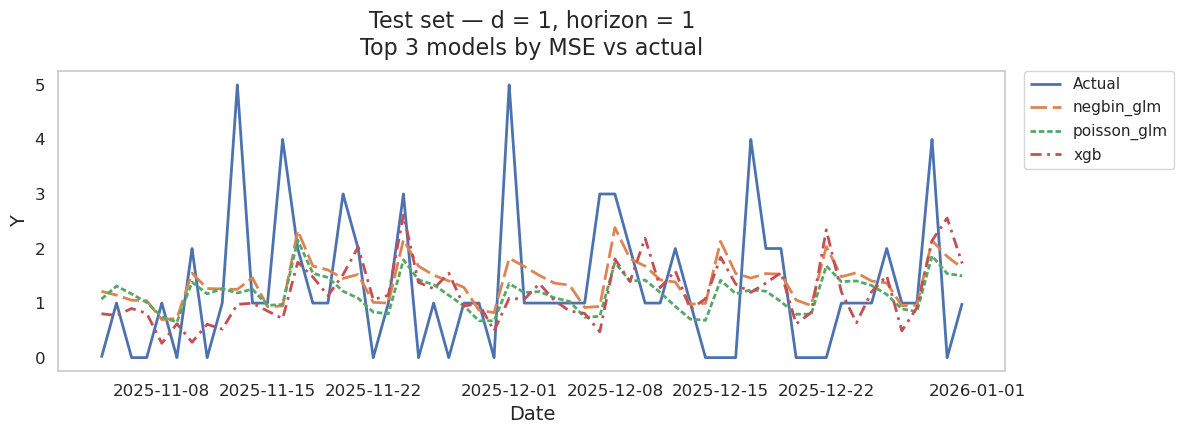

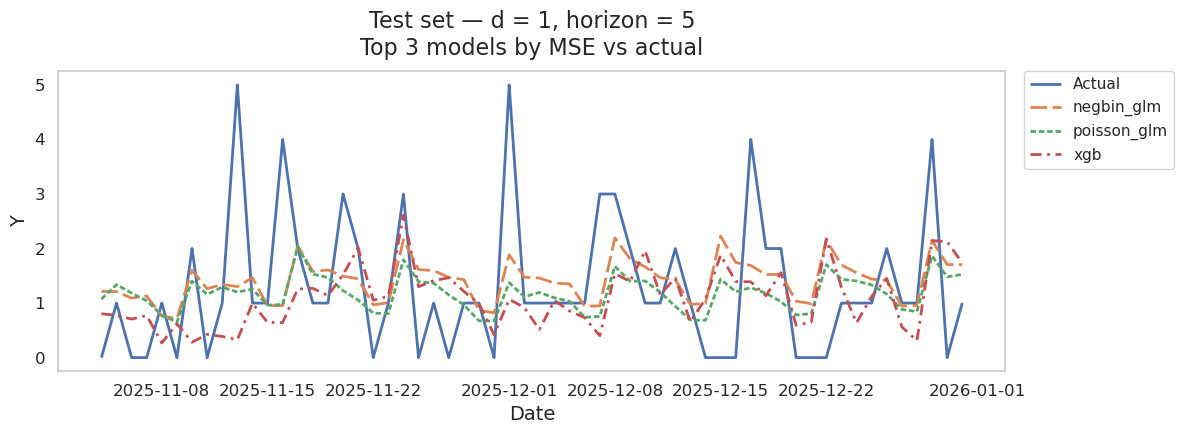

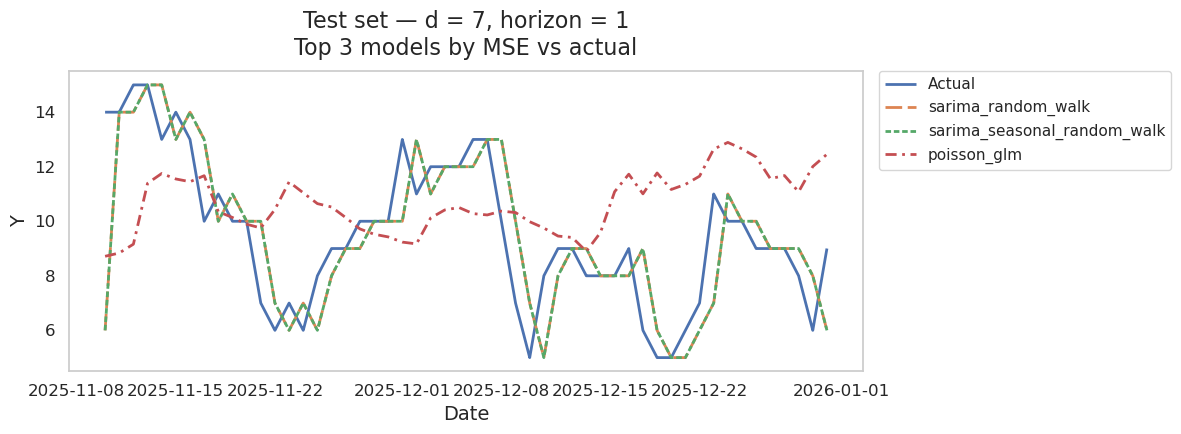

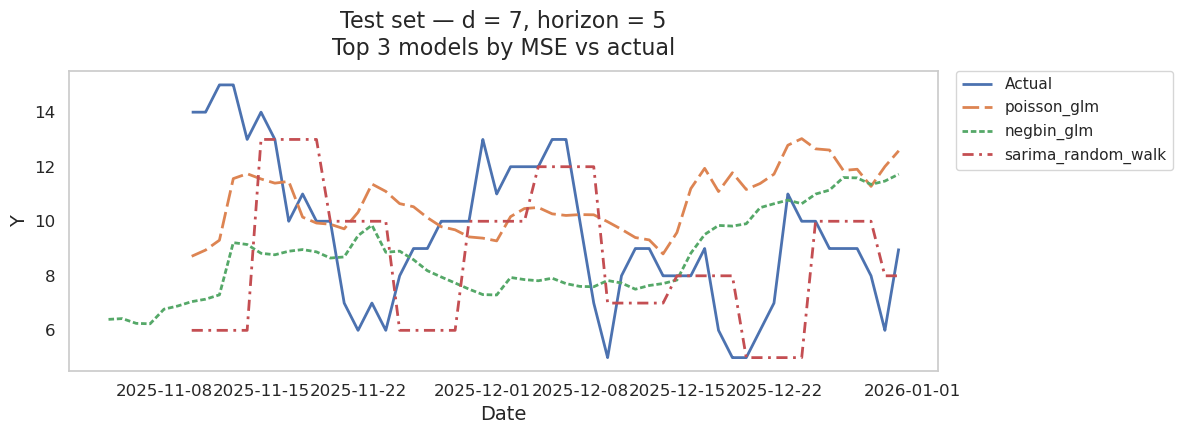

In [48]:
TOP_K_PLOT = 3


def plot_dh_overlay(d_req: int, horizon_h: int):
    key = (d_req, horizon_h)
    if key not in plot_store:
        print(f"No data for (d, horizon_h)={key}")
        return
    if summary_df.empty:
        print("summary_df is empty")
        return

    sub = summary_df[
        (summary_df["d"] == d_req) & (summary_df["horizon_h"] == horizon_h)
    ]
    if sub.empty:
        print(f"No metrics for (d, horizon_h)={key}")
        return

    top_models = sub.nsmallest(TOP_K_PLOT, "rmse")["model_name"].tolist()
    bucket = plot_store[key]
    act = bucket["actual"]
    preds = bucket["preds"]
    if act is None:
        return

    frames = [act.assign(series="Actual")]
    for name in top_models:
        if name in preds:
            frames.append(preds[name].assign(series=name))

    long_df = pd.concat(frames, ignore_index=True)
    series_order = ["Actual"] + [m for m in top_models if m in preds]

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.grid(False)

    n = len(series_order)
    dash_patterns = [(1, 0), (6, 2), (2, 1, 2, 1), (4, 2, 1, 2)][:n]

    sns.lineplot(
        data=long_df,
        x="date",
        y="value",
        hue="series",
        style="series",
        hue_order=series_order,
        style_order=series_order,
        dashes=dash_patterns,
        palette="deep",
        ax=ax,
        estimator=None,
        sort=True,
        linewidth=2,
    )
    ax.set_title(
        f"Test set — d = {d_req}, horizon = {horizon_h - d_req + 1}\n"
        f"Top {TOP_K_PLOT} models by MSE vs actual",
        fontsize=16,
        pad=12,
    )
    ax.set_xlabel("Date", fontsize=14)
    ax.set_ylabel("Y", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(
        title=None,
        fontsize=11,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )
    plt.tight_layout()
    plt.show()


for d_req, horizon_h in DH_GRID:
    plot_dh_overlay(d_req, horizon_h)